# DSAI 2201 Winter 2026 Assignment

In [21]:
NAME =  name "Erum Faisal Khan"



## Assignment 1 - Data Analysis
**(20 points in total)**

In Assignments part 1 & part 2 we will go through the entire journey of a small data science project.

We will utilize one file for this assignment can be downloaded from Kaggle website that you will find attached in the dropbox and you will also find their respective in details in the following links: https://www.kaggle.com/datasets/prateek146/loan-defaulter-classification

### Note 1: Please use the dataset attached in the dropbox as it was modified for the sake of the assignment
### Note 2: Due to the large size of the dataset, visualization/ ML codes might take a considerable amount of time to run



#### Question 1. (2 points)

**A)** Analyze the distribution of loan outcomes (`loan_status`) among borrowers based on their `home_ownership` and `verification_status`.  
Calculate the respective numbers and percentages of each loan status category.

**B)** Compute descriptive statistics of the dataset for all numerical attributes.  
Comment on the results and highlight any notable observations regarding borrower financial profiles.

**C)** Analyze the skewness of the numerical variables distributions.  
Comment on which variables are strongly skewed and discuss possible reasons in a financial context.


#### Question 2. (2 points)

Use univariate plots to analyze patterns in each of the numerical variables with respect to the loan status, comment on them.



#### Question 3. (2 points)

Use multivariate plots (correlation matrix) to:

**A)** Analyze the relationships between numerical variables in the dataset.  
Comment on the strongest correlations and possible financial interpretations.

**B)** Identify potential predictors that may influence loan outcomes (`loan_status`).  
Explain which variables appear to be the most informative.


#### Question 4. (3 points)

Identify and remove any outliers present in the numerical variables .

Explain the rationale behind the method used for detecting outliers and justify why removing or treating them is important in financial data analysis.


#### Question 5. (3 points)

How did you treat missing values in the dataset for the attributes included in your analysis?

Provide a detailed explanation in the comments describing the strategy used and explain why the chosen method is appropriate in a financial risk dataset.


#### Question 6. (3 points)

The dataset contains several numerical attributes where zero values may not be realistic in a financial context.

Identify which attributes cannot logically take the value **0**  and apply an appropriate imputation strategy.  



#### Question 7. (2 points)

Identify the numerical attributes that require rescaling.

Explain why rescaling is necessary for those attributes and apply one of the normalization techniques studied in the course.  



#### Question 8. (3 points)

**A)** Based on domain knowledge and research, propose additional features (feature engineering) that could improve the dataset.  
Explain the logic behind these new attributes and add them to your dataset.

**B)** Identify the most irrelevant attribute(s) in the dataset and exclude them from the analysis for the next steps of the project.  
Justify your reasoning.

## Q1:

Solution:



In [111]:
#importing important libs
import pandas as pd
%pip install matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb 
df = pd.read_csv("NPL.csv")    #read the file

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [117]:
df = pd.read_csv("NPL.csv")  

In [112]:
# Group the data by home ownership and verification status
# Then look at the distribution of loan_status within each group
# value_counts(normalize=True) gives proportions instead of raw counts
# multiply by 100 to convert proportions to percentages

df.groupby(['home_ownership', 'verification_status'])['loan_status'].value_counts(normalize=True).unstack() * 100

loan_status                                  0           1
home_ownership verification_status                        
ANY            Source Verified       50.000000   50.000000
               Verified             100.000000         NaN
MORTGAGE       Not Verified          73.812211   26.187789
               Source Verified       81.083705   18.916295
               Verified              72.900375   27.099625
NONE           Not Verified          17.647059   82.352941
               Source Verified             NaN  100.000000
               Verified              27.777778   72.222222
OTHER          Not Verified          26.785714   73.214286
               Source Verified       30.000000   70.000000
               Verified              17.647059   82.352941
OWN            Not Verified          75.080489   24.919511
               Source Verified       83.275534   16.724466
               Verified              78.194586   21.805414
RENT           Not Verified          68.904561   31.095439
               Source Verified       81.742713   18.257287
               Verified              76.007312   23.992688

In [27]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,...,total_rec_late_fee,recoveries,collection_recovery_fee,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,loan_status
count,5.324280e+05,532428.000000,532428.000000,532428.000000,532428.000000,5.324250e+05,532428.000000,532412.000000,532412.000000,259874.000000,...,532428.000000,532428.000000,532428.000000,532333.000000,132980.000000,532412.000000,490424.000000,4.904240e+05,4.904240e+05,532428.000000
mean,3.500547e+07,14757.595722,14744.271291,14704.926696,13.242969,7.502984e+04,18.138767,0.314448,0.694603,34.055735,...,0.394954,45.717832,4.859221,0.014299,44.121462,0.005015,213.562222,1.395541e+05,3.208057e+04,0.236327
std,2.412148e+07,8434.420080,8429.139277,8441.290381,4.379611,6.519985e+04,8.369074,0.860045,0.997025,21.884797,...,4.091546,409.647467,63.123361,0.133005,22.198410,0.079117,1958.571538,1.539149e+05,3.805304e+04,0.424826
min,7.047300e+04,500.000000,500.000000,0.000000,5.320000,1.200000e+03,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,1.086688e+07,8000.000000,8000.000000,8000.000000,9.990000,4.500000e+04,11.930000,0.000000,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,2.983975e+04,1.400000e+04,0.000000
50%,3.709590e+07,13000.000000,13000.000000,13000.000000,12.990000,6.500000e+04,17.650000,0.000000,0.000000,31.000000,...,0.000000,0.000000,0.000000,0.000000,44.000000,0.000000,0.000000,8.066950e+04,2.370000e+04,0.000000
75%,5.848920e+07,20000.000000,20000.000000,20000.000000,16.200000,9.000000e+04,23.950000,0.000000,1.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,61.000000,0.000000,0.000000,2.084792e+05,3.980000e+04,0.000000
max,7.354484e+07,35000.000000,35000.000000,35000.000000,28.990000,9.500000e+06,672.520000,30.000000,31.000000,180.000000,...,358.680000,33520.270000,7002.190000,16.000000,180.000000,14.000000,496651.000000,8.000078e+06,9.999999e+06,1.000000


In [28]:
# Observations:
# The average loan amount is about 14,750, but it can reach 35,000, indicating that consumers take out comparatively large loans.
# There is a significant difference between low-income and high-income borrowers since the annual income has a very high standard 
# deviation (over 65,000).
# Some variables, such as tot_coll_amt, have a median (50%) of 0 but a mean of 225. 
# This indicates to me that while the majority of people have zero collecting quantities, 
# a small number have really high amounts that raise the average.

In [29]:
df.skew()

/tmp/ipykernel_3664/1665899112.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.skew()


member_id                       0.017368
loan_amnt                       0.681240
funded_amnt                     0.683317
funded_amnt_inv                 0.680642
int_rate                        0.428453
annual_inc                     44.776216
dti                             1.289740
delinq_2yrs                     5.373310
inq_last_6mths                  2.034336
mths_since_last_delinq          0.455529
mths_since_last_record         -0.200317
open_acc                        1.251513
pub_rec                        15.318222
revol_bal                      15.980212
revol_util                     -0.089619
total_acc                       0.893195
total_rec_int                   2.833205
total_rec_late_fee             17.685835
recoveries                     18.076004
collection_recovery_fee        30.838261
collections_12_mths_ex_med     15.760531
mths_since_last_major_derog     0.265863
acc_now_delinq                 27.640411
tot_coll_amt                   61.642207
tot_cur_bal     

In [30]:
#Interpretation:
#Strongly positively skewed variables (high positive values) include annual_inc and tot_coll_amt. This occurs in the financial environment because
#there are always a few "outliers" with extraordinarily large income or debt, while the majority of people have modest earnings and nil collections.
#As a result, the distribution has a lengthy tail to the right.

###  Q2:
Solution:

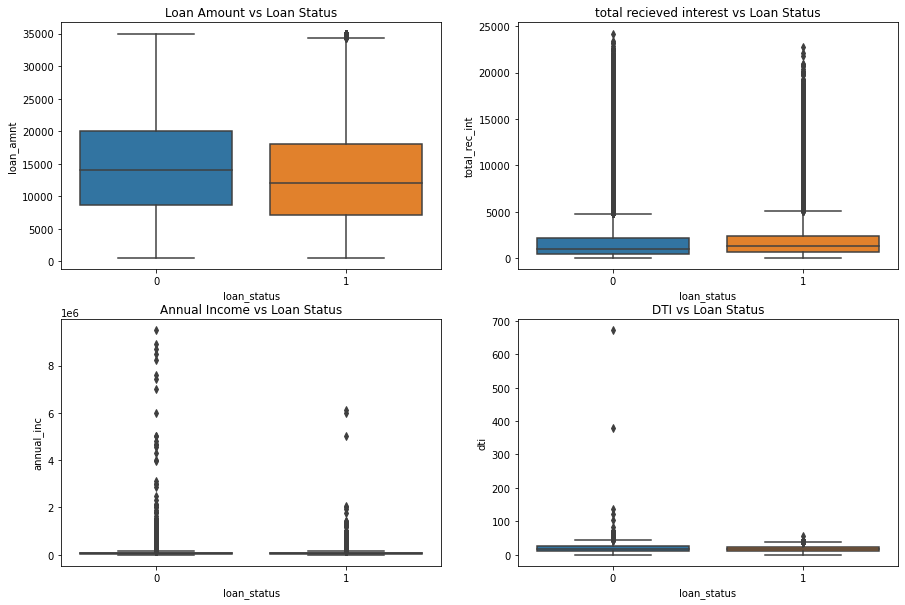

In [31]:
plt.figure(figsize=(15,10))


plt.subplot(2,2,2)
sns.boxplot(x='loan_status', y='total_rec_int', data=df)
plt.title('total recieved interest vs Loan Status')

# Total received interest shows similar medians for both groups,
# but defaulters have many lower and some extreme high values, indicating variable repayments.

plt.subplot(2,2,4)
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title('DTI vs Loan Status')

# DTI distributions overlap heavily, with some outliers, so it does not clearly differentiate default status in this data.

plt.subplot(2,2,3)
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.title('Annual Income vs Loan Status')

#Annual income shows similar wide ranges and outliers in both groups, suggesting it is not strongly related to default here.

plt.subplot(2,2,1)
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount vs Loan Status')

# Loan amounts appear comparable between groups, indicating loan size alone does not strongly predict default in this sample.
plt.show()

###  Q3:

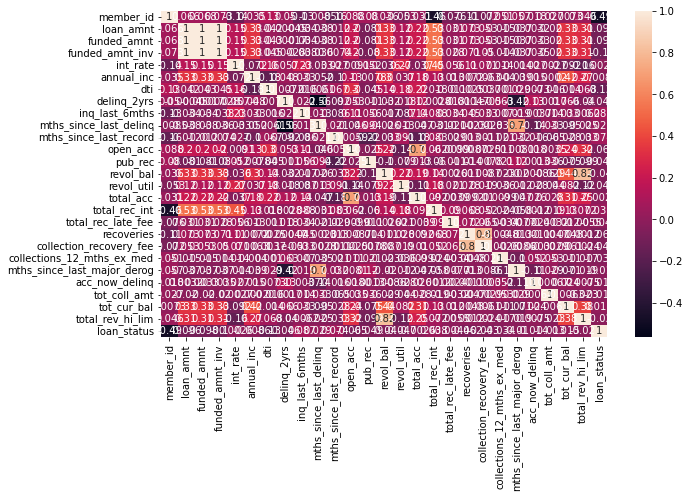

In [32]:
numeric_df = df.select_dtypes(include=[np.number])




plt.figure(figsize=(10,6)) 
sb.heatmap(numeric_df.corr(), annot=True) 
plt.show()

In [33]:
# Summary of key insights from the correlation matrix:

# Strongest predictors for loan default appear to be:
# Interest rate (int_rate)
# Debt-to-income ratio (dti)
# Delinquencies and collections-related variables (delinq_2yrs, acc_now_delinq, collections_12_mths_ex_med)

# Loan amount and income show weaker correlation with default,
# implying that risk is driven more by creditworthiness and financial stress
# rather than loan size or income alone.

###  Q4:
Solution:



In [34]:
# Explanation of the method:
# The Interquartile Range (IQR) method detects outliers by measuring the spread between
# the 25th percentile (Q1) and 75th percentile (Q3) of the data.
# Outliers are values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.
# This approach is robust to skewed data, making it suitable for financial datasets
# that often have heavy-tailed distributions.

# Why remove or treat outliers in financial data?
# Outliers can skew statistical analysis and degrade model performance.
# They may represent data errors, fraud, or rare cases; careful treatment improves model accuracy.
# Removing outliers helps models focus on typical borrower behavior and generalize better.
# Some outliers may hold meaningful information about high-risk borrowers, so removal should be cautious.

# Summary of your implementation:
# 'print_iqr_outliers' identifies and prints outliers for each specified numerical column.
# 'remove_outliers' filters out rows with outliers in any specified column using the IQR rule.
# Printing the shape before and after removal shows the impact of outlier filtering.


In [118]:

def print_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"IQR Outliers in '{column}':")
    print(outliers[[column]])
    return outliers

# 1. Run your existing function to detect & print
outlier_cols = ['loan_amnt', 'annual_inc', 'int_rate', 'dti',
                'funded_amnt', 'funded_amnt_inv', 'delinq_2yrs',
                'inq_last_6mths', 'total_rec_late_fee', 'recoveries']

for col in outlier_cols:
    if col in df.columns:
        print_iqr_outliers(df, col)

# 2. Remove outliers
def remove_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & 
                            (df_clean[col] <= Q3 + 1.5*IQR)]
    return df_clean

# Apply outlier removal
df = remove_outliers(df, outlier_cols)

# Print new shape
print(f"Shape after removing outliers: {df.shape}")

IQR Outliers in 'loan_amnt':
Empty DataFrame
Columns: [loan_amnt]
Index: []
IQR Outliers in 'annual_inc':
        annual_inc
27        250000.0
30        180000.0
31        480000.0
47        168000.0
52        160000.0
...            ...
532306    500000.0
532320    200000.0
532330    165000.0
532336    160000.0
532369    852000.0

[23851 rows x 1 columns]
IQR Outliers in 'int_rate':
        int_rate
204        28.49
212        25.57
417        25.57
513        25.78
571        25.78
...          ...
531820     27.31
531927     25.57
532051     25.57
532239     25.80
532378     27.88

[3674 rows x 1 columns]
IQR Outliers in 'dti':
           dti
13849    44.33
26115    72.30
26588    54.43
38528    44.09
45698    59.19
69315    58.54
69936    52.80
80381    48.56
89003    44.89
92307   120.66
99476    68.41
115012   48.48
137127   61.21
150666   46.28
156238   46.92
165779   68.30
166707  104.00
175764   63.64
195136   71.82
202971   71.40
210844   42.04
223468   64.50
223898   46.71


In [119]:
#data cleaning -> removing extra letters and turning to numeric
df['term'] = df['term'].str.replace(r'[a-z/A-Z]+', '', regex=True)
df['term'] = pd.to_numeric(df['term'], errors='coerce')
df['last_week_pay'] = df['last_week_pay'].str.replace(r'[a-z/A-Z]+', '', regex=True)
df['last_week_pay'] = pd.to_numeric(df['last_week_pay'], errors='coerce')
df['zip_code'] = df['zip_code'].str.replace(r'[a-z/A-Z]+', '', regex=True)
df['zip_code'] = pd.to_numeric(df['zip_code'], errors='coerce')
df['sub_grade'] = df['sub_grade'].str.replace(r'[a-z/A-Z]+', '', regex=True)
df['sub_grade'] = pd.to_numeric(df['sub_grade'], errors='coerce')

In [120]:
# encoding
from sklearn.preprocessing import LabelEncoder

# Create the encoder instance
le = LabelEncoder()

# Encode each categorical column

df['grade'] = le.fit_transform(df['grade'])
df['emp_length'] = le.fit_transform(df['emp_length'])
df['purpose'] = le.fit_transform(df['purpose'])
df['title'] = le.fit_transform(df['title'])
df['addr_state'] = le.fit_transform(df['addr_state'])
df['emp_title'] = le.fit_transform(df['emp_title'])
df['application_type'] = le.fit_transform(df['application_type'])
df['home_ownership'] = le.fit_transform(df['home_ownership'])
df['verification_status'] = le.fit_transform(df['verification_status'])
df['initial_list_status'] = le.fit_transform(df['initial_list_status'])
df['batch_enrolled'] = le.fit_transform(df['batch_enrolled'])
df['pymnt_plan'] = le.fit_transform(df['pymnt_plan'])


###  Q5:

In [123]:
df.isnull().sum()

member_id                     0
loan_amnt                     0
term                          0
batch_enrolled                0
int_rate                      0
grade                         0
sub_grade                     0
emp_title                     0
emp_length                    0
home_ownership                0
annual_inc                    0
verification_status           0
pymnt_plan                    0
purpose                       0
title                         0
zip_code                      0
addr_state                    0
dti                           0
delinq_2yrs                   0
inq_last_6mths                0
mths_since_last_delinq        0
mths_since_last_record        0
open_acc                      0
pub_rec                       0
revol_bal                     0
revol_util                    0
total_acc                     0
initial_list_status           0
collections_12_mths_ex_med    0
application_type              0
acc_now_delinq                0
tot_coll

In [122]:
# Drop columns that are either irrelevant, have many missing values, or add noise

df = df.drop([ 'total_rec_int',
              'total_rec_late_fee', 'recoveries',
              'collection_recovery_fee', 'last_week_pay',
              'funded_amnt', 'funded_amnt_inv', 'verification_status_joint',
             'mths_since_last_major_derog', 'desc'], axis=1, errors='ignore')

# List of numerical columns to fill missing values with median
num_fill = ['annual_inc', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
            'pub_rec', 'total_acc', 'acc_now_delinq', 'revol_util',
            'collections_12_mths_ex_med', 'tot_coll_amt', 
            'tot_cur_bal', 'total_rev_hi_lim', 'mths_since_last_delinq', 'mths_since_last_record', 'emp_length']

for col in num_fill:
    df[col].fillna(df[col].median(), inplace=True)

    


In [ ]:
# Explanation of missing values treatment:

# 1. Dropping irrelevant or problematic columns:
# Some columns like 'total_rec_int','total_rec_late_fee', 'recoveries',
#  'collection_recovery_fee', 'last_week_pay',
#  'funded_amnt', 'funded_amnt_inv', 'verification_status_joint',\
#  'mths_since_last_major_derog', 'desc' are dropped because they have
# too many missing values, redundant information, or are not useful for analysis.
# Removing these simplifies the dataset and reduces noise.

# 2. Numerical columns missing values imputation:
# For numerical columns, missing values are replaced with the median of the column.
# The median is chosen over the mean because it is more robust to outliers
# which are common in financial data. This ensures that imputation does not
# distort the distribution or inflate the risk indicators.

# Overall rationale:
# Using median and mode imputations maintains data integrity while minimizing bias.
# Dropping columns with excessive missing or non-informative data reduces complexity.
# These strategies ensure the dataset is complete and reliable for financial risk modeling.

###  Q6:

In [124]:
cannot_be_zero = ['annual_inc', 'loan_amnt', 'funded_amnt',
                   'funded_amnt_inv', 'int_rate', 'installment']

for col in cannot_be_zero:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].replace(0, median_val)

###  Q7:

In [125]:
from sklearn.preprocessing import StandardScaler

# columns that need scaling
scale_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_bal',
              'tot_cur_bal', 'total_rev_hi_lim',
              'tot_coll_amt']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# check it worked mean should be ~0, std should be ~1
print(df[scale_cols].describe().loc[['mean','std','min','max']].round(2))



      loan_amnt  annual_inc   dti  revol_bal  tot_cur_bal  total_rev_hi_lim  \
mean      -0.00        0.00 -0.00      -0.00         0.00             -0.00   
std        1.00        1.00  1.00       1.00         1.00              1.00   
min       -1.70       -2.17 -2.22      -0.97        -0.97             -1.16   
max        2.54        3.07  2.83      39.36        11.82             39.48   

      tot_coll_amt  
mean          0.00  
std           1.00  
min          -0.10  
max         267.21  


In [126]:
#Why Q7 Requires Rescaling:
#Distances between data points are frequently calculated by machine learning models. 
#The model may believe that the larger feature is more significant if one characteristic (such as annual income) 
#has significantly higher values than another (such as total collection amount). By putting everything on the same scale 
#(mean 0, standard deviation 1), rescaling ensures that every feature is treated equally by the model.

In [127]:
from scipy.stats import mstats

# step 1 - winsorize first
for col in scale_cols:
    if col in df.columns:
        df[col] = mstats.winsorize(df[col], limits=[0.05, 0.05])

# step 2 - scale again
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# check again
print(df[scale_cols].describe().loc[['mean','std','min','max']].round(2))

      loan_amnt  annual_inc   dti  revol_bal  tot_cur_bal  total_rev_hi_lim  \
mean      -0.00        0.00  0.00      -0.00         0.00              0.00   
std        1.00        1.00  1.00       1.00         1.00              1.00   
min       -1.39       -1.41 -1.65      -1.18        -0.98             -1.19   
max        2.07        2.14  1.85       2.44         2.37              2.53   

      tot_coll_amt  
mean          0.00  
std           1.00  
min          -0.32  
max           3.77  


###  Q8:

In [128]:
# Part A: Feature Engineering 

# Feature 1: Credit utilization ratio:
# Measures how much of the available revolving credit is being used.
# revol_bal = current credit card debt
# total_rev_hi_lim = total credit limit
# Higher ratio - borrower is using more of their credit - higher financial stress - higher default risk
df['credit_utilization'] = df['revol_bal'] / (df['total_rev_hi_lim'] + 1)

# Feature 2: Loan per account:
# Measures how large the loan is relative to the number of open credit accounts.
# open_acc = number of active credit accounts
# Higher value: borrower has fewer accounts supporting a large loan - higher concentration risk - higher default risk
df['loan_per_account'] = df['loan_amnt'] / (df['open_acc'] + 1)

In [129]:
drop_cols = [
    'member_id',
    'emp_title',
    'title',
    'zip_code',
    'tot_coll_amt', 
    'acc_now_delinq', 
    'collections_12_mths_ex_med',
    'mths_since_last_delinq', 
    'mths_since_last_record'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [13]:
# Removing columns that are not useful for predicting loan risk:
#
# 1. Columns we drop:
# - 'member_id': Just a unique ID for each borrower; it does not help prediction.
# - 'emp_title' & 'title': Job or loan titles in text form; too detailed, inconsistent, and mostly repeats info from emp_length or income.
# - 'zip_code': Location info; in raw form it can confuse the model because there are too many unique codes.
# - 'tot_coll_amt', 'collections_12_mths_ex_med', 'acc_now_delinq': Past collection or delinquency info; may repeat other credit info and have extreme values.
# - 'mths_since_last_delinq', 'mths_since_last_record': Only meaningful for borrowers with past issues; many missing values.
#
# 2. Why we drop them:
# - Keeps only info that is available when the loan is issued.
# - Makes the dataset smaller and simpler for the model.
# - Reduces noise and repeated info so the model can focus on important predictors.
#
# Result: df now has cleaner, more useful features for predicting loan defaults.

# Assignment Part 2 – Machine Learning Models for Prediction
**Total Points: 15**

In **Assignment Part 1**, we explored and preprocessed the loan dataset, including cleaning the data, handling missing values, removing outliers, rescaling variables, and creating new features.

In **Assignment Part 2**, we will apply supervised machine learning models to perform **classification** and **regression** tasks, evaluate their performance, and identify the most suitable models for each problem.

---

## Classification Problem

Given a dataset of loan applications with information about borrowers and loans, your task is to build a **classification model** that predicts the loan outcome (`loan_status`).

Using a training dataset where the loan status is known, train several machine learning models to predict whether a loan will belong to each loan status category.

You will then evaluate the models and determine which one performs best for predicting loan outcomes.

This problem simulates **credit risk assessment**, where financial institutions aim to predict whether a borrower is likely to **default** or **successfully repay a loan**.

---

## Regression Problem

Your task is to predict the **interest rate (`int_rate`)** assigned to a loan based on borrower and loan characteristics.

Using the training dataset, build **regression models** that estimate the interest rate for new loan applications.

You will evaluate the performance of the regression models and determine which model provides the most accurate predictions.

This problem reflects how financial institutions determine appropriate **interest rates based on borrower risk profiles and financial characteristics**.

#### Question 1. (Data Preparation) (2 points)

### For Classification

List the **relevant features** that you will use to predict the loan outcome (`loan_status`) and explain your answer.

A relevant feature is a variable that may influence whether a borrower successfully repays a loan or is likely to default.



---

### For Regression

List the **relevant features** that you will use to predict the loan interest rate (`int_rate`) and explain your answer.

A relevant feature is a variable that may influence the interest rate assigned to a borrower based on their **financial profile and credit risk**.

###  Data Preparation & Spliting for the Classification Model

In [130]:
%pip install seaborn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [131]:
# Define features (X) and target (y)

X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (372265, 27)
Target shape: (372265,)


In [132]:
# super important: make sure you declare the variable in the correct order.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



Training samples: 297812
Testing samples: 74453


###  Data Preparation & Spliting for the Regression Model

In [137]:
# Define target variable for regression
X = df.drop(['int_rate'], axis=1)
y = df['int_rate']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Question 2. (Classification models)**  _(3 points)_
* Train three different classification models of your choice using the training set. Explain the rationale behind selecting each of these three algorithms. You may refer to the following guidlines for model selection: 
    * Diagram from scikit-learn: https://scikit-learn.org/stable/tutorial/machine_learning_map/
    * Models comparison table: https://docs.google.com/spreadsheets/d/16i47Wmjpj8k-mFRk-NnXXU5tmSQz8h37YxluDV8Zy9U/edit#gid=0



In [18]:
# These three models follow a progression:
# Simple linear model  Non-linear model  Ensemble model

# This aligns with standard model selection practices:
# Start with a simple, interpretable model
# Move to more complex models if needed

# Comparing them helps identify trade-offs between:
# Interpretability (Logistic Regression)
# Flexibility (Decision Tree)
# Accuracy and robustness (Random Forest)

In [133]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression

# Create and train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred_log))
# do not mind the errors, it just means the Logistic Regression was still learning and getting better, but it ran out of time (iterations).

Accuracy: 0.7839710958591326


In [134]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create and train model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))



Accuracy: 0.7553893060051308


In [135]:
# Random Forrest
from sklearn.ensemble import RandomForestClassifier

# Create and train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred_rf))


Accuracy: 0.8263468228278242


**Question 3. (Evaluation of classification models)**  _(3 points)_
* Evaluate the performance of your three classification models on the testing set using the following metrics: accuracy, area under the curve (AUC), precision, and recall.
* Based on the models evaluation results, what is the best model and why?




In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report

models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
    
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"AUC: {auc:.2f}\n")

--- Logistic Regression ---
Accuracy: 0.78
Precision: 0.76
Recall: 0.78
AUC: 0.78

--- Decision Tree ---
Accuracy: 0.76
Precision: 0.76
Recall: 0.76
AUC: 0.68

--- Random Forest ---
Accuracy: 0.83
Precision: 0.83
Recall: 0.83
AUC: 0.83



In [ ]:
# Based on the evaluation metrics, Random Forest is the best model:
# It has the highest accuracy (0.83), precision (0.83), and recall (0.83)
# It also has the highest AUC (0.83), meaning it is the best at distinguishing
#   between loans that will default and loans that will not 
#(“default” means that the borrower fails to repay the loan according to the agreed terms.)
# Logistic Regression performs well but slightly lower than Random Forest
# Decision Tree performs the worst, likely due to overfitting and lower AUC
# Conclusion: Random Forest is preferred for predicting loan status as it 
# balances correct predictions (precision) and capturing most defaults (recall)

**Question 4. (Regression models)**  _(3 points)_
* Train two different regression models of your choice using the training set. Explain the rationale behind selecting each of these two algorithms. 



In [ ]:
# These models show two distinct methods:
#-Linear Regression: easy to understand and straightforward
#-Decision Tree Regressor: adaptable and able to identify patterns that are not linear

#By comparing them, one can ascertain whether the relationship between the goal variable and the traits is linear or more intricate.

# This is a typical modeling methodology:
# begin with a basic model and, if necessary, transition to a more adaptable model.

In [138]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)


print("R²:", r2_score(y_test, y_pred_lin))


R²: 0.9633694279109675


In [139]:
from sklearn.tree import DecisionTreeRegressor

dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

print("R²:", r2_score(y_test, y_pred_dt))


R²: 0.9719663706990859


**Question 5. (Evaluation of regression models)**  _(3 points)_
* Evaluate the performance of your two regression models on the testing set using the following metrics: mean absolute error,mean squared error, and R-square.
* Based on the models evaluation results, what is the best model and why?



In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dictionary of regression models
reg_models = {
    'Linear Regression': lin_model,
    'Decision Tree Regressor': dt_reg
}

# Loop through each model and evaluate
for name, model in reg_models.items():
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R²): {r2:.2f}\n")

--- Linear Regression ---
Mean Squared Error (MSE): 0.65
Mean Absolute Error (MAE): 0.60
R-squared (R²): 0.96

--- Decision Tree Regressor ---
Mean Squared Error (MSE): 0.50
Mean Absolute Error (MAE): 0.33
R-squared (R²): 0.97



In [ ]:
# Comparison of Regression Models:
# 
# Linear Regression:
# - MSE = 0.65, MAE = 0.60, R² = 0.96
# - Performs reasonably well but has higher errors, indicating it struggles with capturing nonlinear patterns.
# 
# Decision Tree Regressor:
# - MSE = 0.50, MAE = 0.33, R² = 0.97
# - Lower errors and slightly higher R² show it predicts the target more accurately and handles nonlinear relationships better.
#
# Conclusion:
# The Decision Tree Regressor is the better choice for this regression task because it produces more accurate predictions with smaller errors compared to Linear Regression.

**Question 6. (Possible improvements)** _(1 points)_
* How can you improve the accuracy of your classification model?
* How can you improve the accuracy of your regression model?

In [ ]:
# To improve the accuracy of classification models:
# - Perform hyperparameter tuning (as done below with GridSearchCV) to find the best settings for each model
# - Use feature engineering to create meaningful features (e.g., loan-to-income ratio, past delinquency)
# - Consider ensemble methods like Random Forest or boosting (e.g., XGBoost, Gradient Boosting)
# - Handle class imbalance if it exists (e.g., oversampling minority class or using class weights)
#
# To improve the accuracy of regression models:
# - Hyperparameter tuning for models like Decision Tree Regressor or Random Forest Regressor
# - Feature scaling and feature selection to remove irrelevant features
# - Try more powerful models like Gradient Boosting, XGBoost, or regularized linear models (Ridge, Lasso)
# - Ensure sufficient training data and handle outliers that can affect predictions

In [48]:
#hypertune the classifiers
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


param_grid_lr = {
    'C': [0.1, 1, 10],              # Regularization strength
    'solver': ['liblinear', 'lbfgs']  # optimization algorithm more on that in later courses
} 

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=3,                # Cross Validation Folds !
    scoring='accuracy',
    n_jobs=-1 #use all CPU cores
)

grid_lr.fit(X_train, y_train)
print("Best LR Params:", grid_lr.best_params_)
print("Best LR Accuracy:", grid_lr.best_score_)


Best LR Params: {'C': 0.1, 'solver': 'liblinear'}
Best LR Accuracy: 0.7634184935951117


In [ ]:
#now the decision tree classifier
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)
print("Best DT Params:", grid_dt.best_params_)
print("Best DT Accuracy:", grid_dt.best_score_)


In [ ]:
#Random Forrest
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF Accuracy:", grid_rf.best_score_)


In [ ]:
# Previous accuracies (before tuning)
acc_before = {
    'Logistic Regression': accuracy_score(y_test, y_pred_log),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf)
}

# New accuracies (after GridSearchCV)
acc_after = {
    'Logistic Regression': grid_lr.best_score_,
    'Decision Tree': grid_dt.best_score_,
    'Random Forest': grid_rf.best_score_
}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = list(acc_before.keys())

# Create lists of values
before_vals = list(acc_before.values())
after_vals = list(acc_after.values())

# Set up bar positions
x = np.arange(len(models))
width = 0.35  # width of bars

# Create plot
plt.figure(figsize=(8,5))
plt.bar(x - width/2, before_vals, width, label='Before Tuning', color='skyblue')
plt.bar(x + width/2, after_vals, width, label='After Tuning', color='seagreen')

# Add text labels
for i, v in enumerate(before_vals):
    plt.text(i - width/2, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=10, fontweight='bold')
for i, v in enumerate(after_vals):
    plt.text(i + width/2, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=10, fontweight='bold')

# Titles and labels
plt.xticks(x, models)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Before and After Hyperparameter Tuning')
plt.ylim(0, 1)
plt.legend()
plt.show()


In [ ]:
#hypertune the regressors
#Linear Regression
param_grid_lin = {
    'fit_intercept': [True, False],
    'positive': [True, False]  # ensures coefficients are non-negative
}

grid_lin = GridSearchCV(
    LinearRegression(),
    param_grid_lin,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_lin.fit(X_train, y_train)
print("Best Linear Regression Params:", grid_lin.best_params_)
print("Best Linear Regression R²:", grid_lin.best_score_)


In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor

param_grid_dt_r = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_dt_r = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt_r,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_dt_r.fit(X_train, y_train)
print("Best Decision Tree Params:", grid_dt_r.best_params_)
print("Best Decision Tree R²:", grid_dt_r.best_score_)


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

param_grid_rf_r = {
    'n_estimators': [50, 100],  
    'max_depth': [5, 10],
}

grid_rf_r = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_r,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf_r.fit(X_train, y_train)
print("Best Random Forest Params:", grid_rf_r.best_params_)
print("Best Random Forest R²:", grid_rf_r.best_score_)


In [ ]:
# R² scores before tuning
r2_before = {
    'Linear Regression': r2_score(y_test, y_pred_lin),
    'Decision Tree': r2_score(y_test, y_pred_dt),
    'Random Forest': r2_score(y_test, y_pred_rf)
}

# R² scores after tuning (from GridSearchCV results)
r2_after = {
    'Linear Regression': grid_lin.best_score_,
    'Decision Tree': grid_dt_r.best_score_,
    'Random Forest': grid_rf_r.best_score_
}

# Convert to lists for plotting
models = list(r2_before.keys())
before_vals = list(r2_before.values())
after_vals = list(r2_after.values())

# Set up bar positions
x = np.arange(len(models))
width = 0.35

# Plot
plt.figure(figsize=(8,5))
plt.bar(x - width/2, before_vals, width, label='Before Tuning', color='lightgreen')
plt.bar(x + width/2, after_vals, width, label='After Tuning', color='seagreen')

# Add value labels on bars
for i, v in enumerate(before_vals):
    plt.text(i - width/2, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=10, fontweight='bold')
for i, v in enumerate(after_vals):
    plt.text(i + width/2, v + 0.01, f"{v*100:.2f}%", ha='center', fontsize=10, fontweight='bold')

# Labels and titles
plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Regression Model Comparison: Before vs After Hyperparameter Tuning')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

# Optional: quick summary table
r2_summary = pd.DataFrame({
    'Model': models,
    'Before Tuning (R²)': before_vals,
    'After Tuning (R²)': after_vals
})
r2_summary